In [1]:
import logging

from preprocessor import Preprocessor
from visualizer import Visualizer
from semantic import SemanticAnalyser
from agent import Agent
from config_local import config


logger = logging.getLogger(__name__)

/home/markoc1120/src/nlp_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


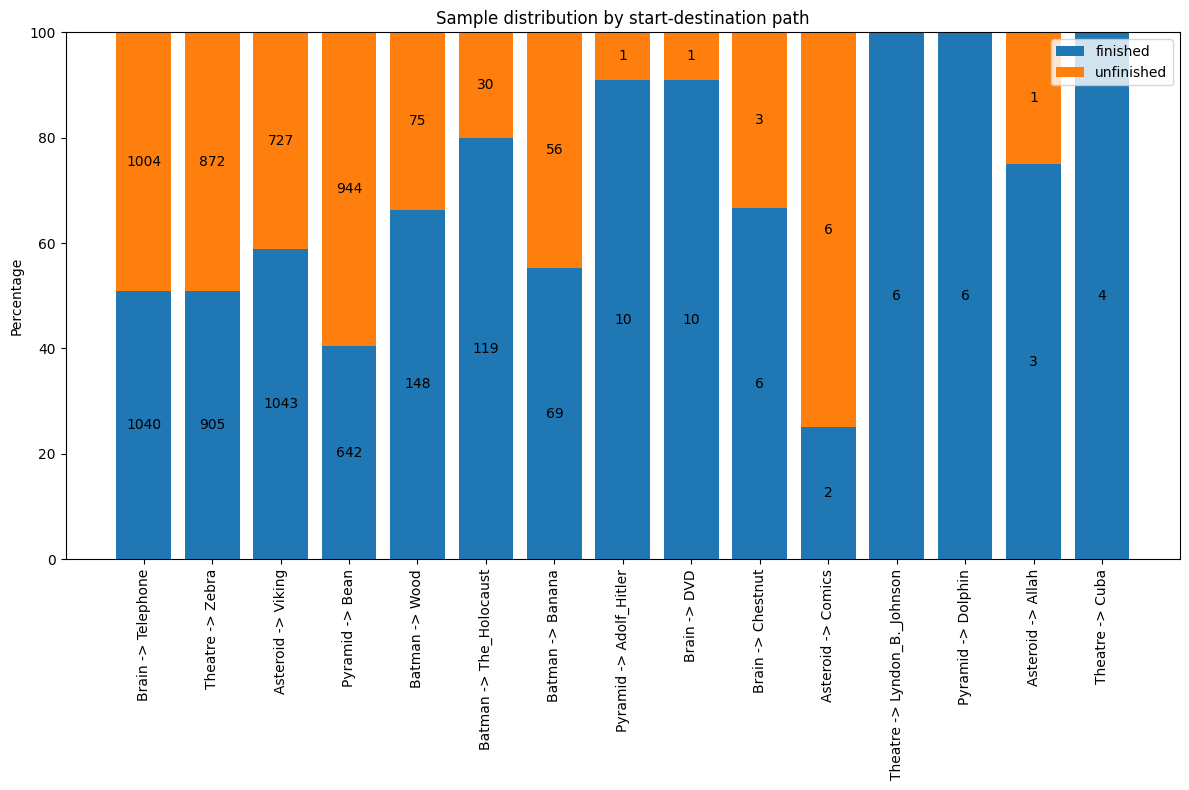

In [2]:
# initializing high level instances, with config
preprocessor = Preprocessor(config=config)
visualizer = Visualizer(config=config)
semantic_analyser = SemanticAnalyser(config=config)

# parse input files into a merged df
df = preprocessor.get_merged_input_files()

# top k start paths with top 3 destination plotted regarding finished/unfinished source
top_k_df = preprocessor.get_top_paths_for_starts(df, 5)
visualizer.visualize_top_k(top_k_df, 'top_k_analysis.png')

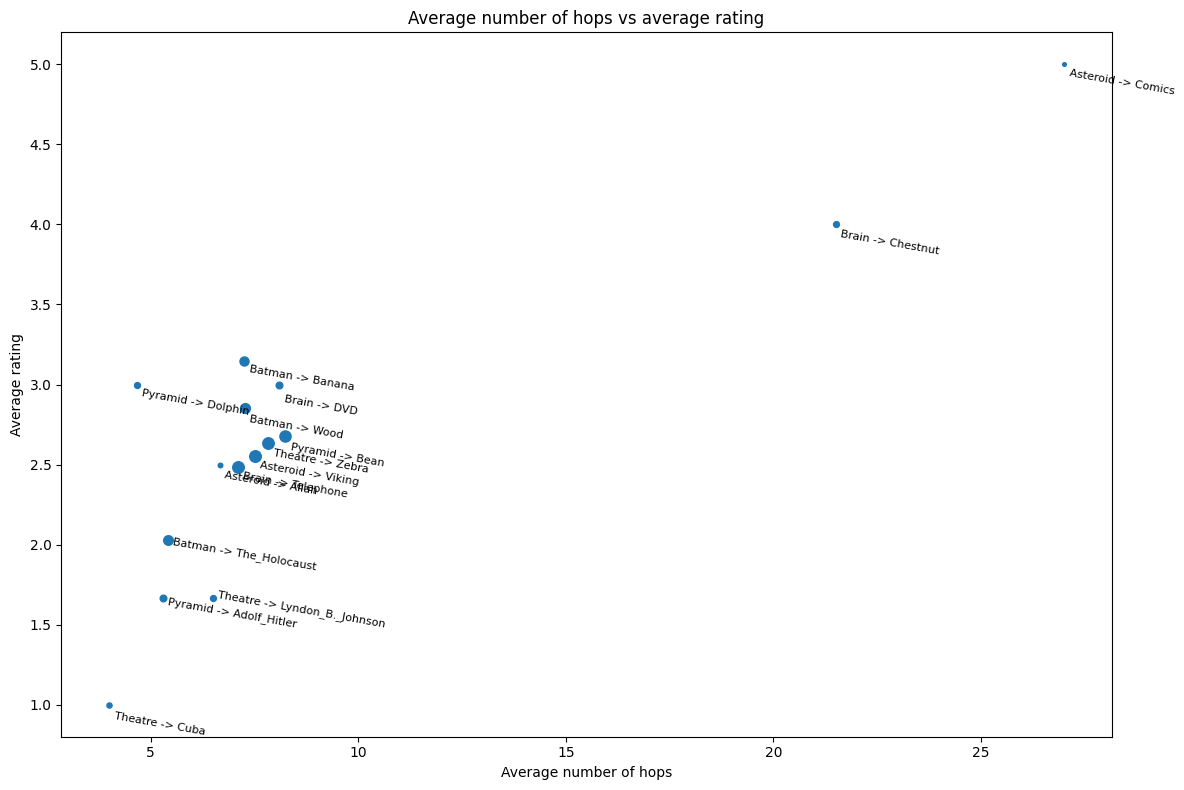

In [3]:
# average hops vs average rating within the above start-destination paths (only for finished paths), scatters are corrected by count [np.log() * 10]
visualizer.visualize_top_k_avg_hops(top_k_df, 'average_hops_vs_average_rating.png')

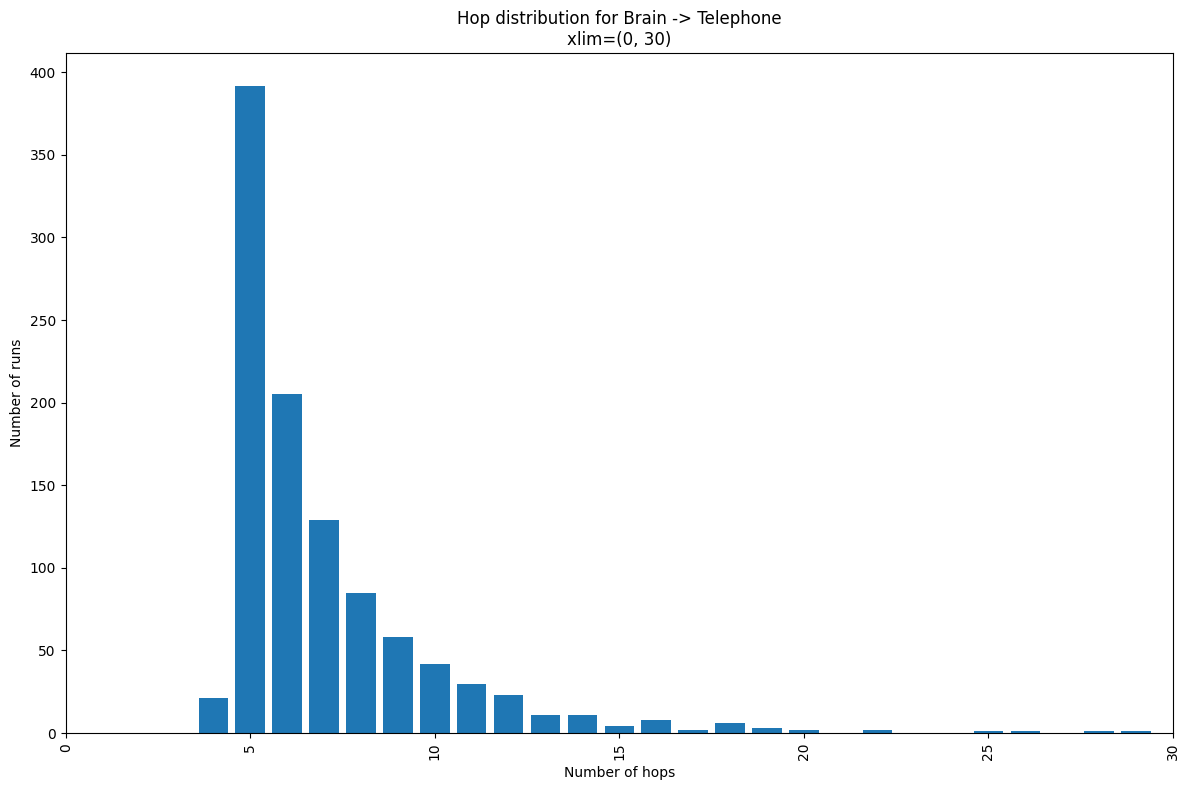

In [4]:
# hop distribtutions for Brain -> Telephone path, only considering finished paths
start, destination = 'Brain', 'Telephone'
hop_distribution = preprocessor.get_hop_distribution(df, start, destination)
visualizer.visualize_hop_distribution(
    hop_distribution,
    'brain_to_telephone_hop_distribution.png',
    (0, 30),
    start,
    destination
)

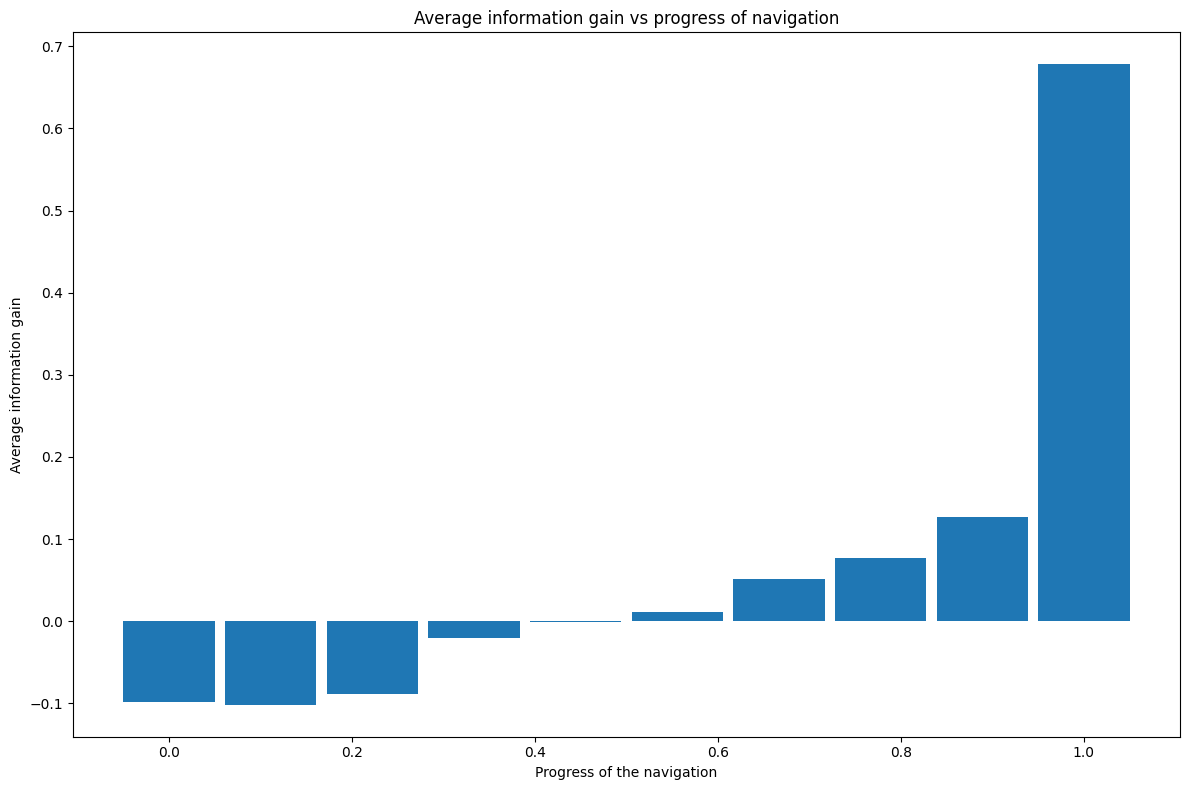

In [5]:
# parse all article titles into a df
articles_df = preprocessor.parse_input_file(config.input_file_articles)

# generate embeddings for all the article titles, also save_dir can be overruled in config
semantic_analyser.generate_embeddings(articles_df)

# get all of the paths for start and destination
paths = preprocessor.get_parsed_paths(df, start, destination)

# calculate information gain by cosine similarity
avg_information_gain = semantic_analyser.get_avg_information_gain(paths)

# visualize information gain against the navigation progress
visualizer.visualize_information_gain(avg_information_gain, 'avg_information_gain_vs_progress.png')

In [6]:
# parsing links.tsv into pd.DataFrame
links_df = preprocessor.parse_input_file('data/wikispeedia_paths-and-graph/links.tsv')

# create link mapping from links_df
link_mappings = preprocessor.get_link_mappings(links_df)

# create high agent instance
agent = Agent(config, link_mappings)
llm_tot_path = agent.navigate_tot(start, destination)
f'Path generated by LLM using ToT: {llm_tot_path}'

"Path generated by LLM using ToT: ['Brain', 'Philosophy_of_mind', 'Computer', 'Telephone']"